In [4]:
#https://github.com/StatQuest/pca_demo/blob/master/pca_demo.py

import pandas as pd
import numpy as np
import random as rd
from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

Trying the Principal Component Analysis on a stock data set, in order to identify how stocks interact with each other, which tells if they are influenced by similar factors.

In [24]:


# Generating the data set
stocks = ['Stock' + str(i) for i in range(1, 11)]
dates = pd.date_range(start='2024-01-01', periods=100, freq='B')  # 100 business days starting from 2024-01-01

# Creating an empty DataFrame with the specified columns (stocks) and index (dates)
data = pd.DataFrame(columns=stocks, index=dates)

# Generating the data set with random numbers from a normal distribution
for stock in data.columns:
    mean_return = rd.uniform(-0.01, 0.01)  # Mean daily return between -1% and 1%
    std_dev_return = rd.uniform(0.001, 0.02)  # Standard deviation between 0.1% and 2%
    data[stock] = np.random.normal(loc=mean_return, scale=std_dev_return, size=len(data))

# Printing the first few rows of the dataset
print(data.head())


              Stock1    Stock2    Stock3    Stock4    Stock5    Stock6  \
2024-01-01  0.002167  0.015432 -0.007763  0.008317  0.002736 -0.004133   
2024-01-02  0.001763 -0.007490 -0.004520  0.009152  0.022024  0.002560   
2024-01-03 -0.004556 -0.004185  0.048503  0.007871 -0.026999  0.002329   
2024-01-04  0.003141 -0.001943  0.001045  0.010835  0.016323 -0.001416   
2024-01-05  0.006344  0.003929  0.013385  0.008641 -0.009620  0.007036   

              Stock7    Stock8    Stock9   Stock10  
2024-01-01  0.012351  0.017830 -0.018951  0.000585  
2024-01-02  0.002181 -0.012086  0.012806  0.009617  
2024-01-03 -0.025638  0.000984  0.034563  0.000292  
2024-01-04 -0.006244 -0.015587 -0.001109  0.011123  
2024-01-05  0.010601 -0.017718 -0.018424  0.011692  


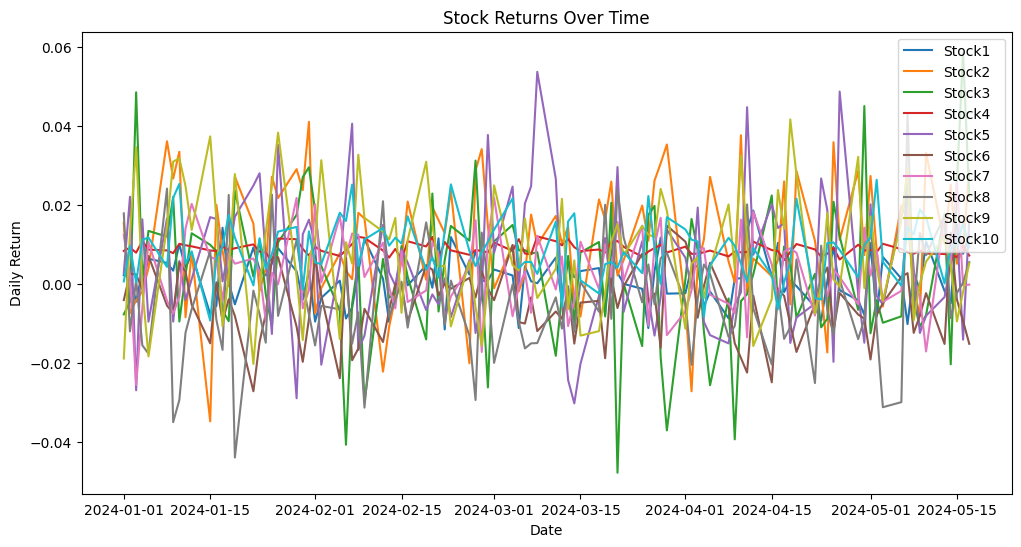

In [25]:
# visualization of daily returns of multiple stocks over time
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(data.index, data[stock], label=stock)
plt.title('Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend(loc='upper right')
plt.show()

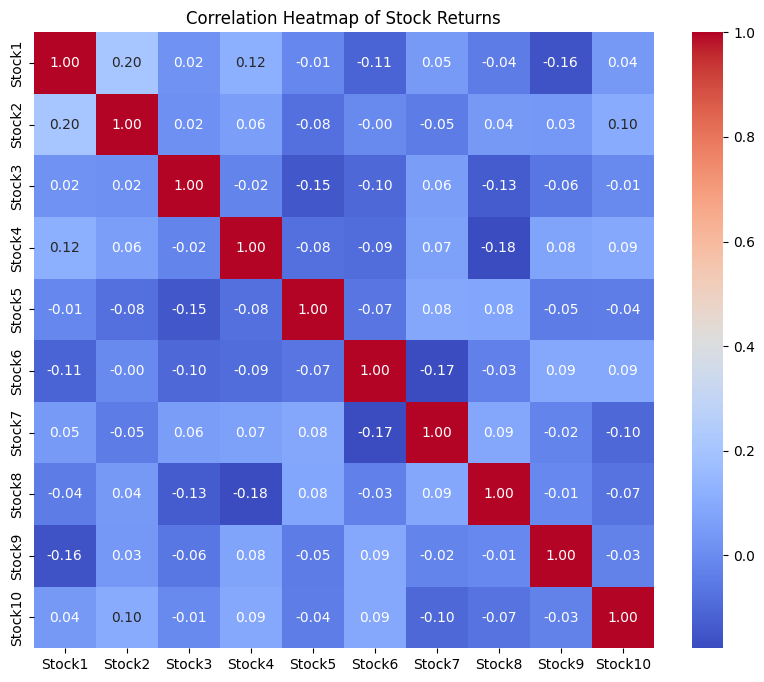

In [26]:
# vizualization of the relationships/correlation between the returns of different stocks
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Stock Returns')
plt.show()

<ipython-input-27-d854122f83dc>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(std_devs[i], mean_returns[i], stock, fontsize=12)


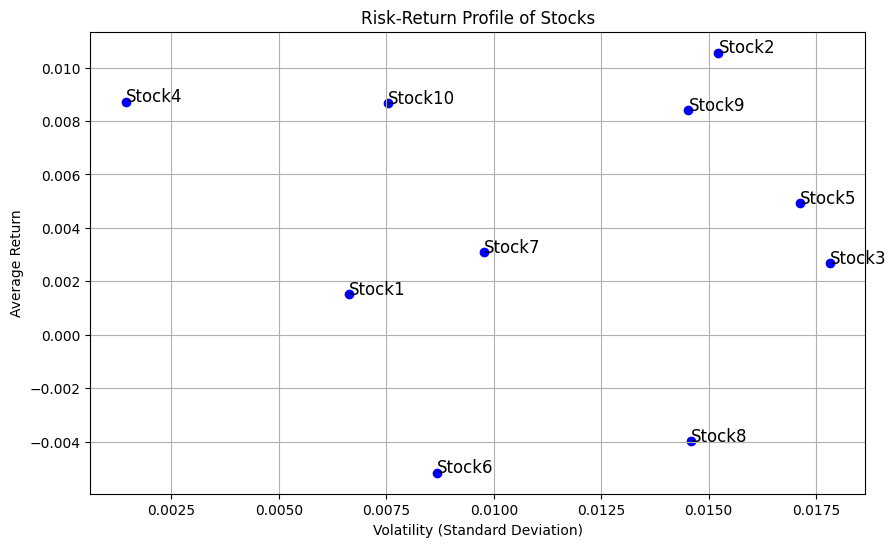

In [27]:
mean_returns = data.mean()
std_devs = data.std()

plt.figure(figsize=(10, 6))
plt.scatter(std_devs, mean_returns, c='blue')
for i, stock in enumerate(stocks):
    plt.text(std_devs[i], mean_returns[i], stock, fontsize=12)
plt.title('Risk-Return Profile of Stocks')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Average Return')
plt.grid(True)
plt.show()

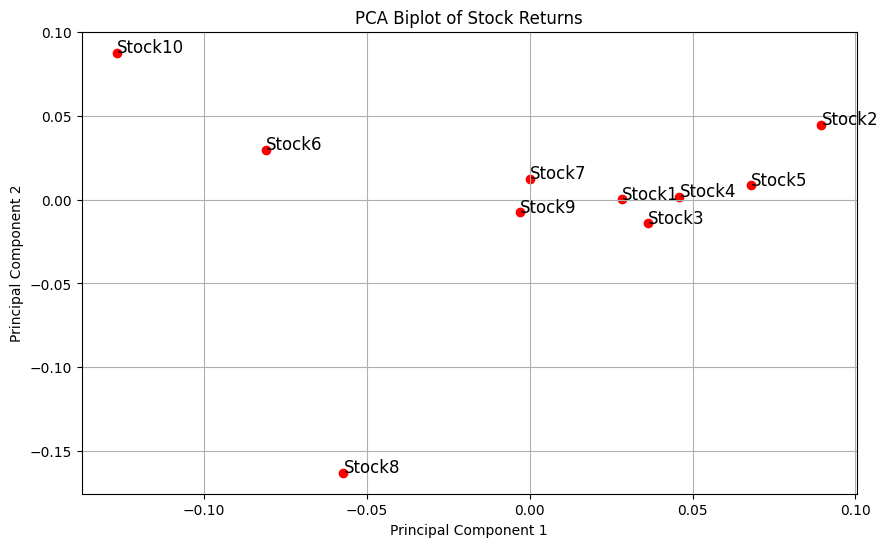

In [40]:
# Perform the Principal Component Analysis on 2 components that explain the highest variance.
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data.T)
pca_df = pd.DataFrame(data=pca_data, index=stocks, columns=['PC1', 'PC2'])

plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='red')
for stock in pca_df.index:
    plt.text(pca_df['PC1'][stock], pca_df['PC2'][stock], stock, fontsize=12)
plt.title('PCA Biplot of Stock Returns')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

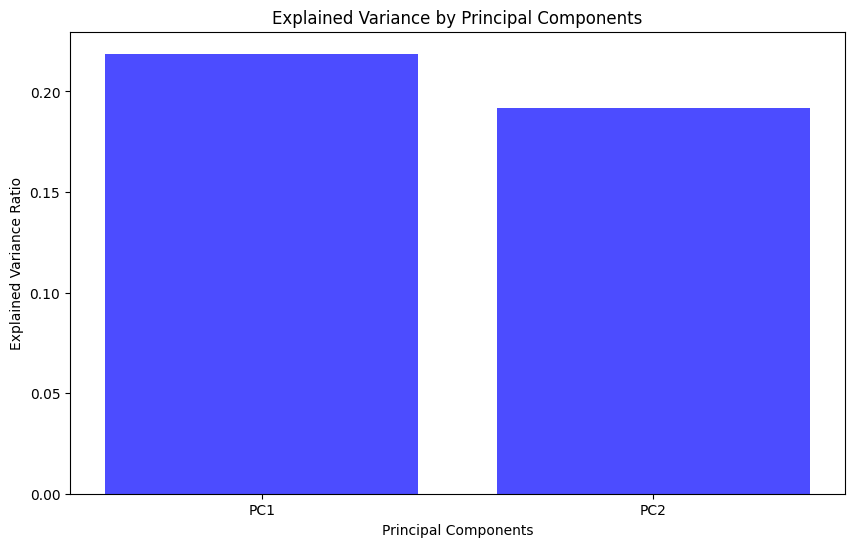

In [42]:
# Explained Variance Plot
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.bar(range(1, 3), explained_variance, alpha=0.7, color='b')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.xticks(range(1, 3), ['PC1', 'PC2'])
plt.show()

In [43]:
print(explained_variance)
# PC1: 21.88%
# PC2: 19.19%

[0.21875937 0.19188262]


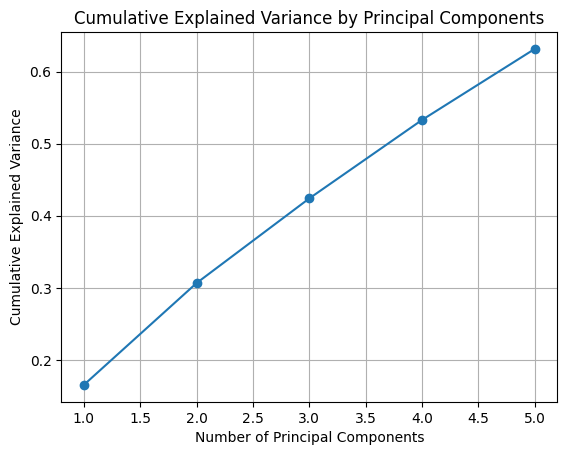

In [37]:
# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
# Plot cumulative explained variance
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Components')
plt.grid(True)
plt.show()

In [38]:
print(cumulative_explained_variance)
#PC1: 16.54%
#PC2: 30.66% (PC1 + PC2)
#PC3: 42.40% (PC1 + PC2 + PC3)
#PC4: 53.28% (PC1 + PC2 + PC3 + PC4)
#PC5: 63.14% (PC1 + PC2 + PC3 + PC4 + PC5)

[0.16539665 0.30659987 0.42402701 0.53283731 0.63135143]


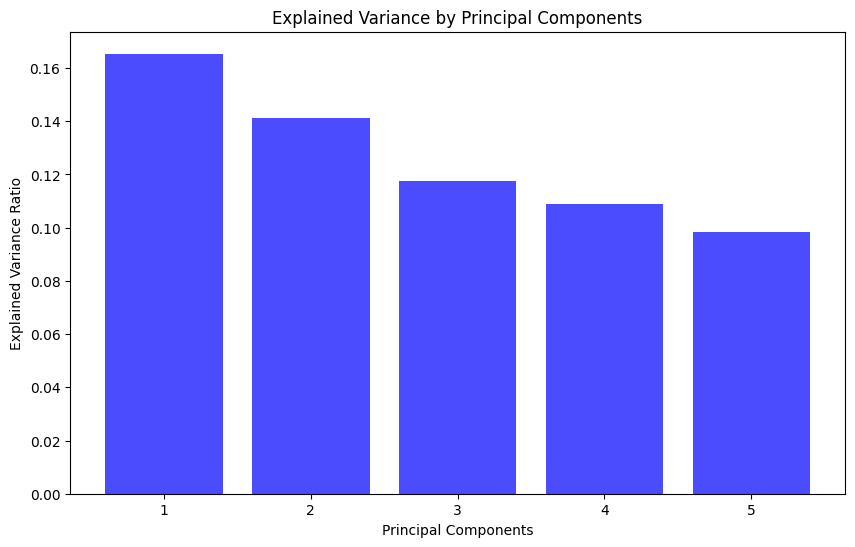

       Stock1    Stock2    Stock3    Stock4    Stock5    Stock6    Stock7  \
PC1 -0.157132 -0.096756 -0.360351 -0.001504 -0.407713  0.428364  0.337070   
PC2 -0.300232 -0.118725  0.239114  0.558242 -0.197525  0.291390 -0.122746   
PC3  0.664855  0.126427 -0.123133  0.071959 -0.186846  0.262417 -0.500728   
PC4 -0.212682  0.735427  0.296530 -0.145448  0.212832  0.260473  0.188928   
PC5  0.010996 -0.382711  0.196438 -0.176816 -0.283285 -0.231155  0.356371   

       Stock8    Stock9   Stock10  
PC1  0.073177 -0.269569  0.542890  
PC2  0.238951  0.575199  0.003556  
PC3  0.392837 -0.112601 -0.011917  
PC4  0.377314 -0.116582 -0.005799  
PC5  0.620999 -0.143308 -0.341612  


In [44]:
#from sklearn.preprocessing import StandardScaler
# Step 1: Generate the Data (as described before)
#stocks = ['Stock' + str(i) for i in range(1, 11)]
#dates = pd.date_range(start='2024-01-01', periods=100, freq='B')
#data = pd.DataFrame(columns=stocks, index=dates)

#for stock in data.columns:
    #mean_return = rd.uniform(-0.01, 0.01)
    #std_dev_return = rd.uniform(0.001, 0.02)
    #data[stock] = np.random.normal(loc=mean_return, scale=std_dev_return, size=len(data))

# Step 2: Standardize the Data
#scaler = StandardScaler()
#scaled_data = scaler.fit_transform(data)  # No transpose needed here

# Perform PCA on 5 Components
pca = PCA(n_components=5)
pca_result = pca.fit_transform(scaled_data)

# Explained Variance Plot
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), explained_variance, alpha=0.7, color='b')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.show()

# PCA Components
pca_df = pd.DataFrame(pca.components_, columns=stocks, index=[f'PC{i+1}' for i in range(5)])
print(pca_df)

In [47]:
# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_explained_variance)
# PC1: 16.54%
# PC2: 30.66% (PC1 + PC2)
# PC3: 42.40% (PC1 + PC2 + PC3)
# PC4: 53.28% (PC1 + PC2 + PC3 + PC4)
# PC5: 63.14% (PC1 + PC2 + PC3 + PC4 + PC5)

[0.16539665 0.30659987 0.42402701 0.53283731 0.63135143]


In [32]:
# Understanding how much each original feature (stock) contributes to each principal component
pca_df = pd.DataFrame(pca.components_, columns=stocks, index=[f'PC{i+1}' for i in range(5)])
print(pca_df)

       Stock1    Stock2    Stock3    Stock4    Stock5    Stock6    Stock7  \
PC1 -0.157132 -0.096756 -0.360351 -0.001504 -0.407713  0.428364  0.337070   
PC2 -0.300232 -0.118725  0.239114  0.558242 -0.197525  0.291390 -0.122746   
PC3  0.664855  0.126427 -0.123133  0.071959 -0.186846  0.262417 -0.500728   
PC4 -0.212682  0.735427  0.296530 -0.145448  0.212832  0.260473  0.188928   
PC5  0.010996 -0.382711  0.196438 -0.176816 -0.283285 -0.231155  0.356371   

       Stock8    Stock9   Stock10  
PC1  0.073177 -0.269569  0.542890  
PC2  0.238951  0.575199  0.003556  
PC3  0.392837 -0.112601 -0.011917  
PC4  0.377314 -0.116582 -0.005799  
PC5  0.620999 -0.143308 -0.341612  


In [33]:
most_important_pc = np.argmax(explained_variance) + 1
print(f"The principal component that explains the most variance is PC{most_important_pc} with an explained variance of {explained_variance[most_important_pc - 1]:.2f}")
# Increasing dimensionality to 5 Principal Components does not improve the results.

The principal component that explains the most variance is PC1 with an explained variance of 0.17
